This notebook is built under four sections:

PART A — Prepare FERPlus

PART B — Cross-domain evaluation

PART C — Performance-gap + error analysis

PART D — Grad-CAM explainability



# **PartA - FERPlus Preparation**

##Basic Setup

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from google.colab import drive
drive.mount("/content/drive")

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
GPU: Tesla T4


##Defining Project Paths

In [ ]:
BASE_DIR = "/content/drive/MyDrive/Emotion_Recognition_Thesis"

DATA_DIR = os.path.join(
    BASE_DIR,
    "datasets"
)

FERPLUS_DIR = os.path.join(
    DATA_DIR,
    "FERPlus"
)

MODEL_DIR = os.path.join(
    BASE_DIR,
    "models"
)

RESULT_DIR = os.path.join(
    BASE_DIR,
    "results"
)

FERPLUS_RESULT_DIR = os.path.join(
    RESULT_DIR,
    "ferplus"
)

os.makedirs(
    FERPLUS_DIR,
    exist_ok=True
)

os.makedirs(
    FERPLUS_RESULT_DIR,
    exist_ok=True
)

print("FERPlus directory:", FERPLUS_DIR)

FERPlus directory: /content/drive/MyDrive/Emotion_Recognition_Thesis/datasets/FERPlus


#Downloading FERPlus annotations

In [ ]:
!wget -q \
https://raw.githubusercontent.com/microsoft/FERPlus/master/fer2013new.csv \
-O "/content/drive/MyDrive/Emotion_Recognition_Thesis/datasets/FERPlus/fer2013new.csv"

print("FERPlus annotation file downloaded.")

FERPlus annotation file downloaded.


In [ ]:
FERPLUS_LABELS_PATH = os.path.join(
    FERPLUS_DIR,
    "fer2013new.csv"
)

print(
    "Exists:",
    os.path.exists(FERPLUS_LABELS_PATH)
)

print(
    "Size:",
    os.path.getsize(FERPLUS_LABELS_PATH)
)

Exists: True
Size: 1602762


#Loading FERPlus Annotations

In [ ]:
ferplus_labels = pd.read_csv(
    FERPLUS_LABELS_PATH
)

print(
    "Shape:",
    ferplus_labels.shape
)

print(
    "\nColumns:"
)

print(
    ferplus_labels.columns.tolist()
)

ferplus_labels.head()

Shape: (35887, 12)

Columns:
['Usage', 'Image name', 'neutral', 'happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear', 'contempt', 'unknown', 'NF']


,Usage,Image name,neutral,happiness,surprise,sadness,anger,disgust,fear,contempt,unknown,NF
0,Training,fer0000000.png,4,0,0,1,3,2,0,0,0,0
1,Training,fer0000001.png,6,0,1,1,0,0,0,0,2,0
2,Training,fer0000002.png,5,0,0,3,1,0,0,0,1,0
3,Training,fer0000003.png,4,0,0,4,1,0,0,0,1,0
4,Training,fer0000004.png,9,0,0,1,0,0,0,0,0,0


In [ ]:
for root, dirs, files in os.walk(DATA_DIR):

    for file in files:

        if "fer2013" in file.lower():

            print(
                os.path.join(
                    root,
                    file
                )
            )

/content/drive/MyDrive/Emotion_Recognition_Thesis/datasets/FERPlus/fer2013new.csv


In [ ]:
FER2013_DIR = os.path.join(
    DATA_DIR,
    "FER2013"
)

os.makedirs(
    FER2013_DIR,
    exist_ok=True
)

print(FER2013_DIR)

/content/drive/MyDrive/Emotion_Recognition_Thesis/datasets/FER2013


In [ ]:
!wget -q --show-progress \
"https://huggingface.co/datasets/DerrickUnleashed/FER-2013/resolve/main/icml_face_data.csv?download=true" \
-O "/content/drive/MyDrive/Emotion_Recognition_Thesis/datasets/FER2013/icml_face_data.csv"

/content/drive/MyDr 100%[===================>] 287.12M  47.3MB/s    in 7.3s    


In [ ]:
FER2013_PATH = os.path.join(
    FER2013_DIR,
    "icml_face_data.csv"
)

print(
    "Exists:",
    os.path.exists(FER2013_PATH)
)

print(
    "Size MB:",
    round(
        os.path.getsize(FER2013_PATH) / (1024**2),
        2
    )
)

Exists: True
Size MB: 287.13


In [ ]:
fer2013_df = pd.read_csv(
    FER2013_PATH
)

print(
    "Shape:",
    fer2013_df.shape
)

print(
    "Columns:",
    fer2013_df.columns.tolist()
)

fer2013_df.head()

Shape: (35887, 3)
Columns: ['emotion', ' Usage', ' pixels']


,emotion,Usage,pixels
0,0,Training,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,Training,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,Training,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,Training,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,Training,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...


In [ ]:
print("FER2013 shape:", fer2013_df.shape)
print("FER2013 columns:", fer2013_df.columns.tolist())

print()

print("FERPlus shape:", ferplus_labels.shape)
print("FERPlus columns:", ferplus_labels.columns.tolist())

FER2013 shape: (35887, 3)
FER2013 columns: ['emotion', ' Usage', ' pixels']

FERPlus shape: (35887, 12)
FERPlus columns: ['Usage', 'Image name', 'neutral', 'happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear', 'contempt', 'unknown', 'NF']


In [ ]:
fer2013_df.columns = [
    col.strip()
    for col in fer2013_df.columns
]

ferplus_labels.columns = [
    col.strip()
    for col in ferplus_labels.columns
]

print("FER2013 columns:")
print(fer2013_df.columns.tolist())

print("\nFERPlus columns:")
print(ferplus_labels.columns.tolist())

FER2013 columns:
['emotion', 'Usage', 'pixels']

FERPlus columns:
['Usage', 'Image name', 'neutral', 'happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear', 'contempt', 'unknown', 'NF']


In [ ]:
print("FER2013 rows:", len(fer2013_df))
print("FERPlus rows:", len(ferplus_labels))

assert len(fer2013_df) == len(ferplus_labels)

print("✓ Row counts match.")


FER2013 rows: 35887
FERPlus rows: 35887
✓ Row counts match.


In [ ]:
usage_match = (
    fer2013_df["Usage"]
    .astype(str)
    .str.strip()
    .values
    ==
    ferplus_labels["Usage"]
    .astype(str)
    .str.strip()
    .values
)

print(
    "Usage rows matching:",
    usage_match.sum(),
    "/",
    len(usage_match)
)

print(
    "All Usage rows match:",
    usage_match.all()
)

Usage rows matching: 35887 / 35887
All Usage rows match: True


##Inspecting Usage Splits

In [ ]:
print("FER2013 Usage:")
print(
    fer2013_df["Usage"]
    .value_counts()
)

print("\nFERPlus Usage:")
print(
    ferplus_labels["Usage"]
    .value_counts()
)

FER2013 Usage:
Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64

FERPlus Usage:
Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64


In [ ]:
sample_pixels = np.array(
    fer2013_df.iloc[0]["pixels"].split(),
    dtype=np.uint8
)

print(
    "Pixel count:",
    len(sample_pixels)
)

print(
    "Expected:",
    48 * 48
)

Pixel count: 2304
Expected: 2304


##Visualize FERPlus samples

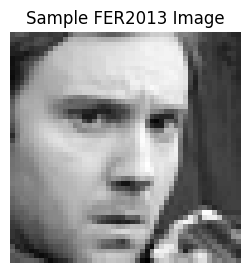

In [ ]:
sample_image = sample_pixels.reshape(
    48,
    48
)

plt.figure(
    figsize=(3, 3)
)

plt.imshow(
    sample_image,
    cmap="gray"
)

plt.title(
    "Sample FER2013 Image"
)

plt.axis("off")

plt.show()

In [ ]:
ferplus_labels.columns = [
    col.strip().lower()
    for col in ferplus_labels.columns
]

print(
    ferplus_labels.columns.tolist()
)

['usage', 'image name', 'neutral', 'happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear', 'contempt', 'unknown', 'nf']


In [ ]:
ALL_VOTE_COLUMNS = [
    "neutral",
    "happiness",
    "surprise",
    "sadness",
    "anger",
    "disgust",
    "fear",
    "contempt",
    "unknown",
    "nf"
]

ferplus_labels[
    "total_votes"
] = ferplus_labels[
    ALL_VOTE_COLUMNS
].sum(axis=1)

print(
    ferplus_labels[
        "total_votes"
    ].describe()
)

count    35887.000000
mean         9.999972
std          0.005279
min          9.000000
25%         10.000000
50%         10.000000
75%         10.000000
max         10.000000
Name: total_votes, dtype: float64


In [ ]:
print(
    ferplus_labels[
        "total_votes"
    ].value_counts()
    .sort_index()
)

total_votes
9         1
10    35886
Name: count, dtype: int64


In [ ]:
EMOTION_CLASSES = [
    "anger",
    "contempt",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

NUM_CLASSES = len(
    EMOTION_CLASSES
)

class_to_idx = {
    emotion: idx
    for idx, emotion
    in enumerate(
        EMOTION_CLASSES
    )
}

print(class_to_idx)

{'anger': 0, 'contempt': 1, 'disgust': 2, 'fear': 3, 'happy': 4, 'neutral': 5, 'sad': 6, 'surprise': 7}


In [ ]:
FERPLUS_EMOTION_COLUMNS = [
    "neutral",
    "happiness",
    "surprise",
    "sadness",
    "anger",
    "disgust",
    "fear",
    "contempt"
]

In [ ]:
ferplus_to_common = {
    "neutral": "neutral",
    "happiness": "happy",
    "surprise": "surprise",
    "sadness": "sad",
    "anger": "anger",
    "disgust": "disgust",
    "fear": "fear",
    "contempt": "contempt"
}

##Implement FERPlus majority-vote labels

In [ ]:
def get_ferplus_majority_label(row):

    emotion_votes = np.array(
        [
            row[col]
            for col
            in FERPLUS_EMOTION_COLUMNS
        ],
        dtype=float
    )

    unknown_votes = float(
        row["unknown"]
    )

    nf_votes = float(
        row["nf"]
    )

    all_votes = np.concatenate(
        [
            emotion_votes,
            [unknown_votes, nf_votes]
        ]
    )

    total_votes = all_votes.sum()

    if total_votes == 0:
        return None

    winner_idx = np.argmax(
        all_votes
    )

    winner_votes = all_votes[
        winner_idx
    ]

    # Require absolute majority
    if winner_votes <= (
        total_votes / 2
    ):
        return None

    # Ignore unknown and NF
    if winner_idx >= len(
        FERPLUS_EMOTION_COLUMNS
    ):
        return None

    ferplus_emotion = (
        FERPLUS_EMOTION_COLUMNS[
            winner_idx
        ]
    )

    return ferplus_to_common[
        ferplus_emotion
    ]

In [ ]:
ferplus_labels[
    "common_emotion"
] = ferplus_labels.apply(
    get_ferplus_majority_label,
    axis=1
)

In [ ]:
print(
    ferplus_labels[
        "common_emotion"
    ].value_counts(
        dropna=False
    )
)

common_emotion
neutral     9494
happy       8802
None        8485
surprise    3461
sad         2958
anger       2096
fear         430
contempt      95
disgust       66
Name: count, dtype: int64


##Merge FER2013 image data and FERPlus annotations

In [ ]:
combined_df = pd.DataFrame({
    "pixels":
        fer2013_df["pixels"].values,

    "usage":
        fer2013_df["Usage"]
        .astype(str)
        .str.strip()
        .values,

    "emotion":
        ferplus_labels[
            "common_emotion"
        ].values
})

In [ ]:
print(
    "Combined shape:",
    combined_df.shape
)

combined_df.head()

Combined shape: (35887, 3)


,pixels,usage,emotion
0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training,None
1,151 150 147 155 148 133 111 140 170 174 182 15...,Training,neutral
2,231 212 156 164 174 138 161 173 182 200 106 38...,Training,None
3,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training,None
4,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training,neutral


In [ ]:
print(
    "Before filtering:",
    len(combined_df)
)

combined_clean_df = (
    combined_df
    .dropna(
        subset=["emotion"]
    )
    .reset_index(drop=True)
)

print(
    "After filtering:",
    len(combined_clean_df)
)

print(
    "Excluded ambiguous samples:",
    len(combined_df)
    - len(combined_clean_df)
)

Before filtering: 35887
After filtering: 27402
Excluded ambiguous samples: 8485


In [ ]:
combined_clean_df[
    "label"
] = combined_clean_df[
    "emotion"
].map(
    class_to_idx
)

print(
    combined_clean_df[
        "label"
    ].value_counts()
    .sort_index()
)

label
0    2096
1      95
2      66
3     430
4    8802
5    9494
6    2958
7    3461
Name: count, dtype: int64


#Select the official external test split

In [ ]:
ferplus_test_df = (
    combined_clean_df[
        combined_clean_df[
            "usage"
        ] == "PrivateTest"
    ]
    .copy()
    .reset_index(drop=True)
)

In [ ]:
print(
    "FERPlus external test size:",
    len(ferplus_test_df)
)

print(
    "\nClass distribution:"
)

print(
    ferplus_test_df[
        "emotion"
    ].value_counts()
)

FERPlus external test size: 2729

Class distribution:
emotion
neutral     936
happy       872
surprise    341
sad         295
anger       219
fear         50
contempt      9
disgust       7
Name: count, dtype: int64


In [ ]:
ferplus_distribution = (
    ferplus_test_df[
        "emotion"
    ]
    .value_counts()
    .reindex(
        EMOTION_CLASSES
    )
)

ferplus_distribution_df = pd.DataFrame({
    "Emotion":
        ferplus_distribution.index,

    "Count":
        ferplus_distribution.values,

    "Percentage":
        (
            ferplus_distribution.values
            /
            len(ferplus_test_df)
            * 100
        )
})

ferplus_distribution_df

,Emotion,Count,Percentage
0,anger,219,8.024918
1,contempt,9,0.329791
2,disgust,7,0.256504
3,fear,50,1.832173
4,happy,872,31.953096
5,neutral,936,34.298278
6,sad,295,10.809820
7,surprise,341,12.495420


In [ ]:
ferplus_distribution_df.to_csv(
    os.path.join(
        FERPLUS_RESULT_DIR,
        "ferplus_test_distribution.csv"
    ),
    index=False
)

# **PART B - Cross Domain Evaluation**

##FERPlus Preprocessing

In [ ]:
from torchvision import transforms

ferplus_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

##FERPlus PyTorch Dataset

In [ ]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class FERPlusDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):
        self.dataframe = dataframe.reset_index(
            drop=True
        )

        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        pixels = np.array(
            row["pixels"].split(),
            dtype=np.uint8
        )

        image_array = pixels.reshape(
            48,
            48
        )

        # ResNet50 requires 3 channels
        image = Image.fromarray(
            image_array
        ).convert("RGB")

        label = int(
            row["label"]
        )

        if self.transform:
            image = self.transform(
                image
            )

        return image, label

##Create external test DataLoader

In [ ]:
ferplus_test_dataset = FERPlusDataset(
    ferplus_test_df,
    transform=ferplus_transform
)

ferplus_test_loader = DataLoader(
    ferplus_test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(
    "FERPlus test images:",
    len(ferplus_test_dataset)
)

images, labels = next(
    iter(ferplus_test_loader)
)

print(
    "Image batch shape:",
    images.shape
)

print(
    "Label batch shape:",
    labels.shape
)

print(
    "Image dtype:",
    images.dtype
)

FERPlus test images: 2729
Image batch shape: torch.Size([64, 3, 224, 224])
Label batch shape: torch.Size([64])
Image dtype: torch.float32


In [ ]:
print("Common class mapping:")

for emotion, idx in class_to_idx.items():
    print(
        f"{idx}: {emotion}"
    )

Common class mapping:
0: anger
1: contempt
2: disgust
3: fear
4: happy
5: neutral
6: sad
7: surprise


In [ ]:
print(
    "Labels present in FERPlus:",
    sorted(
        ferplus_test_df[
            "label"
        ].unique()
    )
)

Labels present in FERPlus: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


##Load weighted ResNet50

In [ ]:
import torch.nn as nn
from torchvision.models import resnet50

weighted_resnet = resnet50(
    weights=None
)

weighted_resnet.fc = nn.Linear(
    weighted_resnet.fc.in_features,
    NUM_CLASSES
)

checkpoint_path = os.path.join(
    MODEL_DIR,
    "resnet50_weighted_best.pth"
)

weighted_resnet.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=device
    )
)

weighted_resnet = weighted_resnet.to(
    device
)

weighted_resnet.eval()

print(
    "Loaded:",
    checkpoint_path
)

print(
    "Model device:",
    next(
        weighted_resnet.parameters()
    ).device
)

Loaded: /content/drive/MyDrive/Emotion_Recognition_Thesis/models/resnet50_weighted_best.pth
Model device: cuda:0


##Define evaluation function

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

def evaluate_external_model(
    model,
    loader,
    device
):

    model.eval()

    y_true = []
    y_pred = []
    confidences = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                device
            )

            outputs = model(
                images
            )

            probabilities = torch.softmax(
                outputs,
                dim=1
            )

            confidence, predictions = (
                probabilities.max(
                    dim=1
                )
            )

            y_true.extend(
                labels.numpy()
            )

            y_pred.extend(
                predictions
                .cpu()
                .numpy()
            )

            confidences.extend(
                confidence
                .cpu()
                .numpy()
            )

    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "precision": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "recall": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "macro_f1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "weighted_f1": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "y_true": np.array(
            y_true
        ),

        "y_pred": np.array(
            y_pred
        ),

        "confidence": np.array(
            confidences
        )
    }

##THE important cross-domain test

In [ ]:
ferplus_results = evaluate_external_model(
    weighted_resnet,
    ferplus_test_loader,
    device
)

print(
    "=== FERPlus Cross-Dataset Evaluation ==="
)

print(
    f"Accuracy:        "
    f"{ferplus_results['accuracy']:.4f}"
)

print(
    f"Macro Precision: "
    f"{ferplus_results['precision']:.4f}"
)

print(
    f"Macro Recall:    "
    f"{ferplus_results['recall']:.4f}"
)

print(
    f"Macro F1:        "
    f"{ferplus_results['macro_f1']:.4f}"
)

print(
    f"Weighted F1:     "
    f"{ferplus_results['weighted_f1']:.4f}"
)

=== FERPlus Cross-Dataset Evaluation ===
Accuracy:        0.0744
Macro Precision: 0.1067
Macro Recall:    0.2067
Macro F1:        0.0674
Weighted F1:     0.0455


In [ ]:
ferplus_report = classification_report(
    ferplus_results["y_true"],
    ferplus_results["y_pred"],
    labels=list(range(NUM_CLASSES)),
    target_names=EMOTION_CLASSES,
    digits=4,
    zero_division=0
)

print(
    "\nClassification Report:\n"
)

print(
    ferplus_report
)


Classification Report:

              precision    recall  f1-score   support

       anger     0.1639    0.1781    0.1707       219
    contempt     0.0217    0.1111    0.0364         9
     disgust     0.0000    0.0000    0.0000         7
        fear     0.0265    0.9800    0.0516        50
       happy     0.0000    0.0000    0.0000       872
     neutral     0.0000    0.0000    0.0000       936
         sad     0.1968    0.3729    0.2576       295
    surprise     0.4444    0.0117    0.0229       341

    accuracy                         0.0744      2729
   macro avg     0.1067    0.2067    0.0674      2729
weighted avg     0.0905    0.0744    0.0455      2729



In [ ]:
AFFECTNET_ACCURACY = 0.5942
AFFECTNET_MACRO_F1 = 0.5517

##Calculate the cross-domain gap

In [ ]:
accuracy_gap = (
    AFFECTNET_ACCURACY
    -
    ferplus_results[
        "accuracy"
    ]
)

macro_f1_gap = (
    AFFECTNET_MACRO_F1
    -
    ferplus_results[
        "macro_f1"
    ]
)

print(
    "=== Cross-Dataset Performance Gap ==="
)

print(
    f"AffectNet Accuracy: "
    f"{AFFECTNET_ACCURACY:.4f}"
)

print(
    f"FERPlus Accuracy:   "
    f"{ferplus_results['accuracy']:.4f}"
)

print(
    f"Accuracy Gap:       "
    f"{accuracy_gap:.4f}"
)

print()

print(
    f"AffectNet Macro-F1: "
    f"{AFFECTNET_MACRO_F1:.4f}"
)

print(
    f"FERPlus Macro-F1:   "
    f"{ferplus_results['macro_f1']:.4f}"
)

print(
    f"Macro-F1 Gap:       "
    f"{macro_f1_gap:.4f}"
)

=== Cross-Dataset Performance Gap ===
AffectNet Accuracy: 0.5942
FERPlus Accuracy:   0.0744
Accuracy Gap:       0.5198

AffectNet Macro-F1: 0.5517
FERPlus Macro-F1:   0.0674
Macro-F1 Gap:       0.4843


In [ ]:
print(
    f"Accuracy gap: "
    f"{accuracy_gap * 100:.2f} percentage points"
)

print(
    f"Macro-F1 gap: "
    f"{macro_f1_gap * 100:.2f} percentage points"
)

Accuracy gap: 51.98 percentage points
Macro-F1 gap: 48.43 percentage points


In [ ]:
ferplus_report_dict = classification_report(
    ferplus_results["y_true"],
    ferplus_results["y_pred"],
    labels=list(range(NUM_CLASSES)),
    target_names=EMOTION_CLASSES,
    output_dict=True,
    zero_division=0
)

ferplus_report_df = pd.DataFrame(
    ferplus_report_dict
).transpose()

ferplus_report_df.to_csv(
    os.path.join(
        FERPLUS_RESULT_DIR,
        "ferplus_classification_report.csv"
    )
)

In [ ]:
cross_domain_results = pd.DataFrame({
    "Dataset": [
        "AffectNet",
        "FERPlus"
    ],

    "Accuracy": [
        AFFECTNET_ACCURACY,
        ferplus_results[
            "accuracy"
        ]
    ],

    "Macro_F1": [
        AFFECTNET_MACRO_F1,
        ferplus_results[
            "macro_f1"
        ]
    ]
})

cross_domain_results.to_csv(
    os.path.join(
        FERPLUS_RESULT_DIR,
        "cross_domain_results.csv"
    ),
    index=False
)

cross_domain_results

,Dataset,Accuracy,Macro_F1
0,AffectNet,0.594200,0.551700
1,FERPlus,0.074386,0.067386


In [ ]:
ferplus_predictions_df = (
    ferplus_test_df.copy()
)

ferplus_predictions_df[
    "predicted_label"
] = ferplus_results[
    "y_pred"
]

ferplus_predictions_df[
    "predicted_emotion"
] = [
    EMOTION_CLASSES[i]
    for i in ferplus_results[
        "y_pred"
    ]
]

ferplus_predictions_df[
    "confidence"
] = ferplus_results[
    "confidence"
]

ferplus_predictions_df[
    "correct"
] = (
    ferplus_predictions_df[
        "label"
    ].values
    ==
    ferplus_results[
        "y_pred"
    ]
)

ferplus_predictions_df.to_csv(
    os.path.join(
        FERPLUS_RESULT_DIR,
        "ferplus_predictions.csv"
    ),
    index=False
)

print(
    "FERPlus predictions saved."
)

FERPlus predictions saved.


In [ ]:
from collections import Counter

true_counts = Counter(
    ferplus_results["y_true"]
)

pred_counts = Counter(
    ferplus_results["y_pred"]
)

print("TRUE LABEL DISTRIBUTION")
for i, emotion in enumerate(EMOTION_CLASSES):
    print(
        f"{i} {emotion:10s}: "
        f"{true_counts.get(i, 0)}"
    )

print("\nPREDICTED LABEL DISTRIBUTION")
for i, emotion in enumerate(EMOTION_CLASSES):
    print(
        f"{i} {emotion:10s}: "
        f"{pred_counts.get(i, 0)}"
    )

TRUE LABEL DISTRIBUTION
0 anger     : 219
1 contempt  : 9
2 disgust   : 7
3 fear      : 50
4 happy     : 872
5 neutral   : 936
6 sad       : 295
7 surprise  : 341

PREDICTED LABEL DISTRIBUTION
0 anger     : 238
1 contempt  : 46
2 disgust   : 27
3 fear      : 1850
4 happy     : 0
5 neutral   : 0
6 sad       : 559
7 surprise  : 9


In [ ]:
def pixels_to_image(pixel_string):
    """
    Convert a FER2013 pixel string into
    a 48x48 grayscale NumPy image.
    """

    pixels = np.array(
        str(pixel_string).split(),
        dtype=np.uint8
    )

    if len(pixels) != 48 * 48:
        raise ValueError(
            f"Expected 2304 pixels, got {len(pixels)}"
        )

    image = pixels.reshape(
        48,
        48
    )

    return image

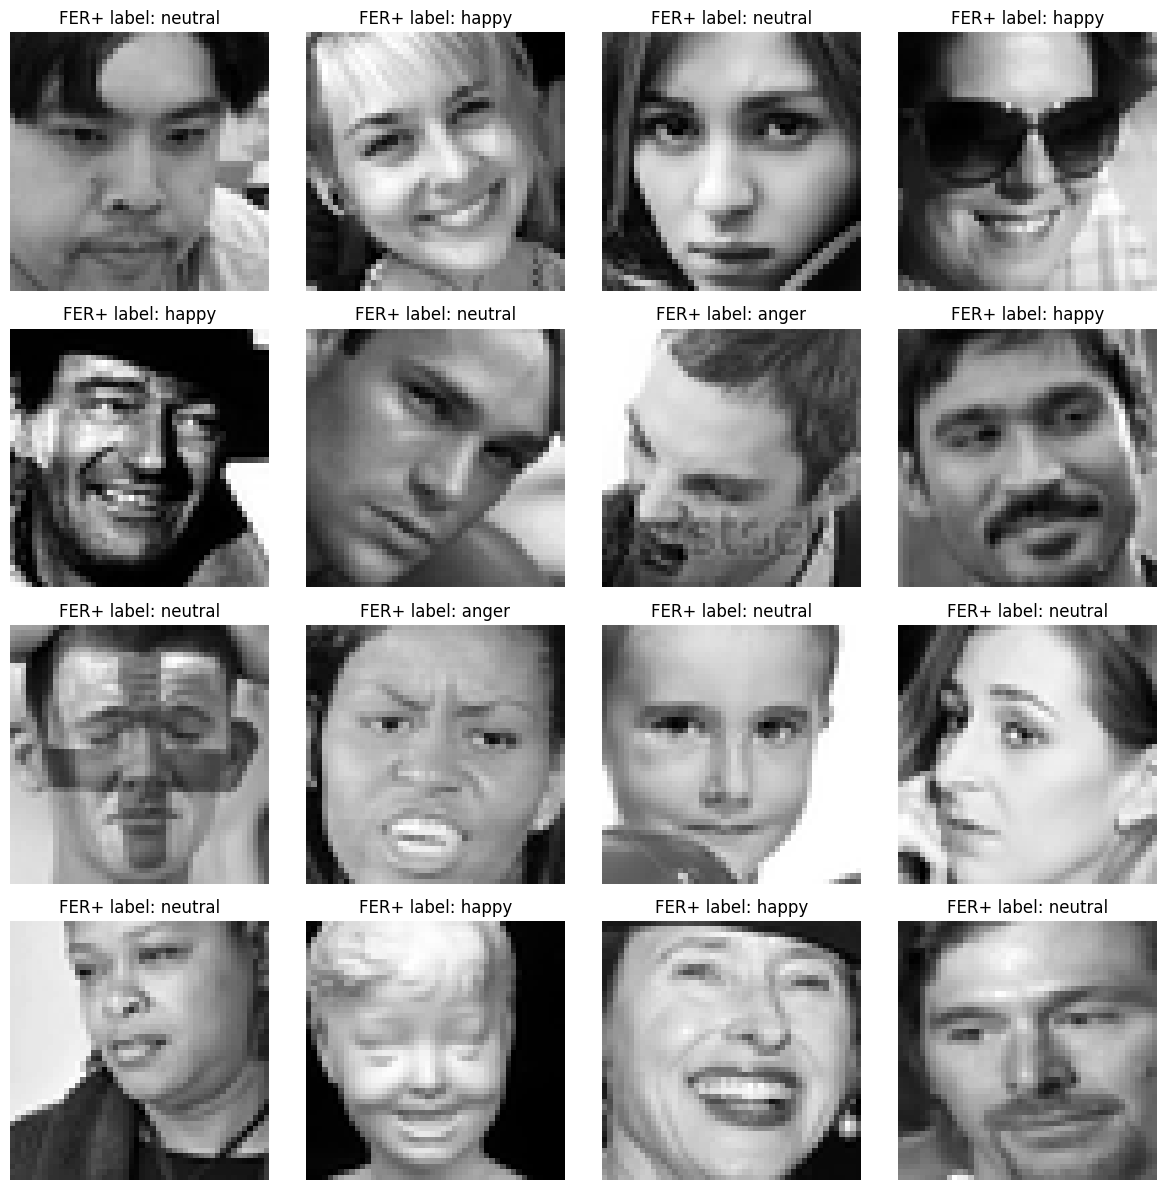

In [ ]:
fig, axes = plt.subplots(
    4,
    4,
    figsize=(12, 12)
)

sample_df = ferplus_test_df.sample(
    16,
    random_state=123
)

for ax, (_, row) in zip(
    axes.flatten(),
    sample_df.iterrows()
):

    image = pixels_to_image(
        row["pixels"]
    )

    ax.imshow(
        image,
        cmap="gray"
    )

    ax.set_title(
        f"FER+ label: {row['emotion']}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

Shape: (48, 48)
Data type: uint8
Min pixel: 45
Max pixel: 255


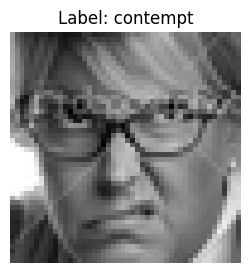

In [ ]:
test_image = pixels_to_image(
    ferplus_test_df.iloc[0]["pixels"]
)

print("Shape:", test_image.shape)
print("Data type:", test_image.dtype)
print("Min pixel:", test_image.min())
print("Max pixel:", test_image.max())

plt.figure(figsize=(3, 3))
plt.imshow(test_image, cmap="gray")
plt.title(
    f"Label: {ferplus_test_df.iloc[0]['emotion']}"
)
plt.axis("off")
plt.show()

In [ ]:
print(
    ferplus_labels[
        ["usage", "image name"]
    ].head(20)
)

       usage      image name
0   Training  fer0000000.png
1   Training  fer0000001.png
2   Training  fer0000002.png
3   Training  fer0000003.png
4   Training  fer0000004.png
5   Training  fer0000005.png
6   Training  fer0000006.png
7   Training  fer0000007.png
8   Training  fer0000008.png
9   Training  fer0000009.png
10  Training  fer0000010.png
11  Training  fer0000011.png
12  Training  fer0000012.png
13  Training  fer0000013.png
14  Training  fer0000014.png
15  Training  fer0000015.png
16  Training  fer0000016.png
17  Training             NaN
18  Training  fer0000018.png
19  Training  fer0000019.png


In [ ]:
print(
    ferplus_labels[
        ["usage", "image name"]
    ].tail(20)
)

             usage      image name
35867  PrivateTest  fer0035782.png
35868  PrivateTest  fer0035783.png
35869  PrivateTest  fer0035784.png
35870  PrivateTest  fer0035785.png
35871  PrivateTest  fer0035786.png
35872  PrivateTest  fer0035787.png
35873  PrivateTest  fer0035788.png
35874  PrivateTest  fer0035789.png
35875  PrivateTest  fer0035790.png
35876  PrivateTest  fer0035791.png
35877  PrivateTest  fer0035792.png
35878  PrivateTest  fer0035793.png
35879  PrivateTest  fer0035794.png
35880  PrivateTest  fer0035795.png
35881  PrivateTest  fer0035796.png
35882  PrivateTest  fer0035797.png
35883  PrivateTest             NaN
35884  PrivateTest  fer0035799.png
35885  PrivateTest  fer0035800.png
35886  PrivateTest  fer0035801.png


In [ ]:
FER2013_CLASSES = {
    0: "anger",
    1: "disgust",
    2: "fear",
    3: "happy",
    4: "sad",
    5: "surprise",
    6: "neutral"
}

In [ ]:
diagnostic_df = pd.DataFrame({
    "original_fer2013_label":
        fer2013_df["emotion"].values,

    "ferplus_label":
        ferplus_labels[
            "common_emotion"
        ].values,

    "usage":
        fer2013_df[
            "Usage"
        ].values
})

diagnostic_df[
    "original_emotion"
] = diagnostic_df[
    "original_fer2013_label"
].map(
    FER2013_CLASSES
)

In [ ]:
pd.crosstab(
    diagnostic_df[
        "original_emotion"
    ],
    diagnostic_df[
        "ferplus_label"
    ],
    normalize="index"
).round(3)

ferplus_label,anger,contempt,disgust,fear,happy,neutral,sad,surprise
original_emotion,,,,,,,,
anger,0.559,0.012,0.003,0.005,0.023,0.309,0.067,0.023
disgust,0.196,0.129,0.284,0.005,0.026,0.077,0.278,0.005
fear,0.093,0.004,0.000,0.125,0.028,0.371,0.219,0.160
happy,0.001,0.000,0.000,0.000,0.943,0.040,0.001,0.015
neutral,0.001,0.002,0.000,0.000,0.060,0.906,0.029,0.002
sad,0.014,0.002,0.000,0.002,0.010,0.521,0.443,0.007
surprise,0.006,0.000,0.000,0.015,0.074,0.041,0.004,0.860


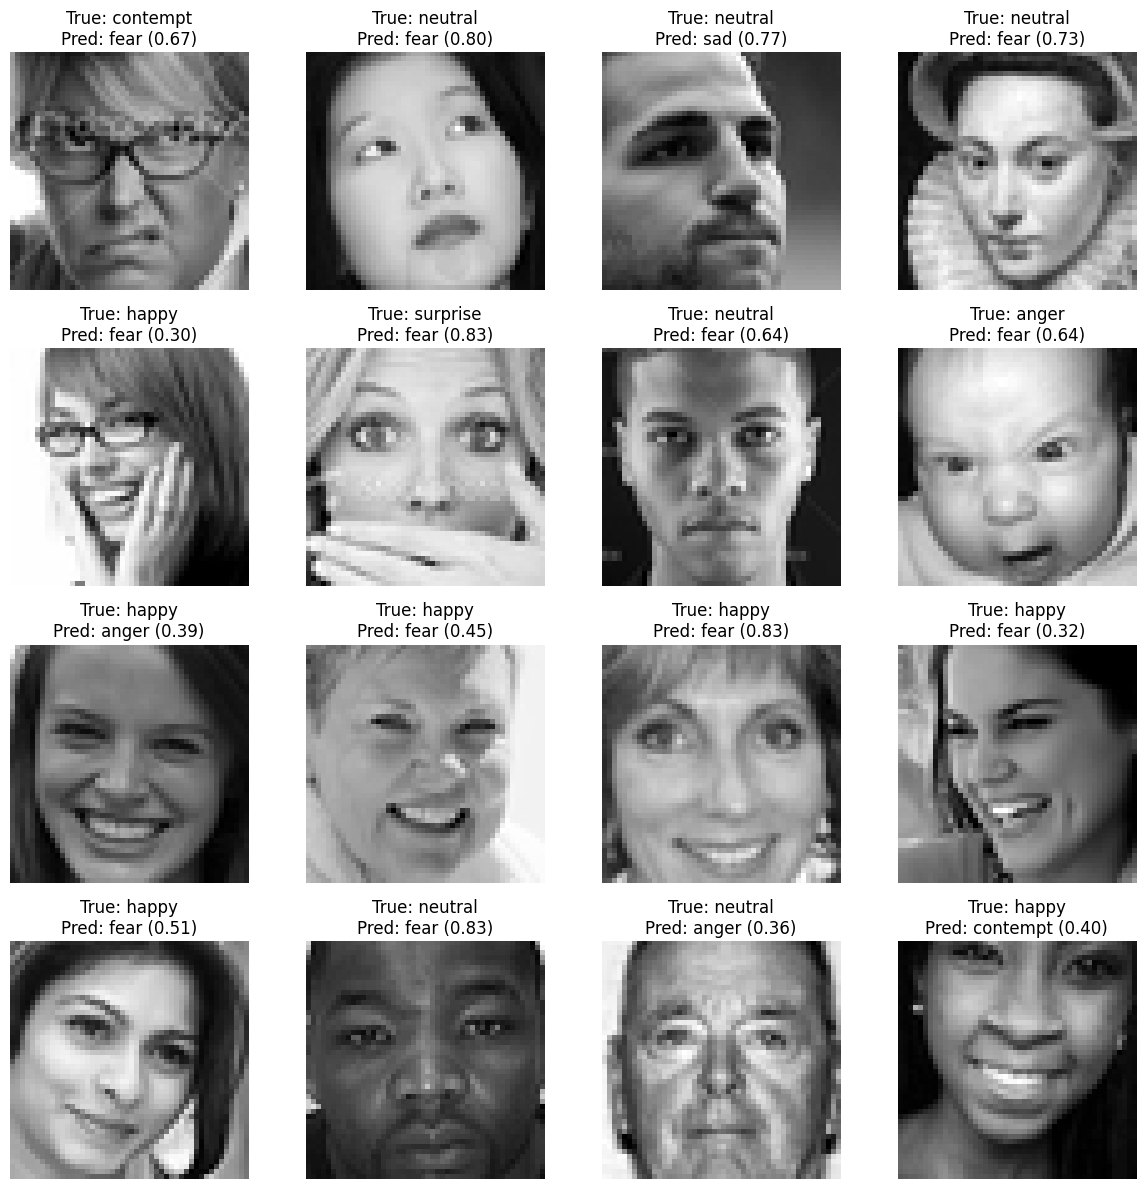

In [ ]:
fig, axes = plt.subplots(
    4,
    4,
    figsize=(12, 12)
)

indices = np.linspace(
    0,
    len(ferplus_test_df) - 1,
    16,
    dtype=int
)

for ax, idx in zip(
    axes.flatten(),
    indices
):

    row = ferplus_test_df.iloc[idx]

    image = pixels_to_image(
        row["pixels"]
    )

    true_emotion = row[
        "emotion"
    ]

    pred_idx = ferplus_results[
        "y_pred"
    ][idx]

    predicted_emotion = (
        EMOTION_CLASSES[
            pred_idx
        ]
    )

    confidence = ferplus_results[
        "confidence"
    ][idx]

    ax.imshow(
        image,
        cmap="gray"
    )

    ax.set_title(
        f"True: {true_emotion}\n"
        f"Pred: {predicted_emotion} "
        f"({confidence:.2f})"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
print(
    "Mean confidence:",
    ferplus_results[
        "confidence"
    ].mean()
)

print(
    "Median confidence:",
    np.median(
        ferplus_results[
            "confidence"
        ]
    )
)

print(
    "Maximum confidence:",
    ferplus_results[
        "confidence"
    ].max()
)

Mean confidence: 0.565091
Median confidence: 0.53592014
Maximum confidence: 0.9777233


In [ ]:
def denormalize_image(tensor):

    mean = torch.tensor(
        [0.485, 0.456, 0.406]
    ).view(3, 1, 1)

    std = torch.tensor(
        [0.229, 0.224, 0.225]
    ).view(3, 1, 1)

    image = (
        tensor.cpu() * std
        + mean
    )

    image = torch.clamp(
        image,
        0,
        1
    )

    return image

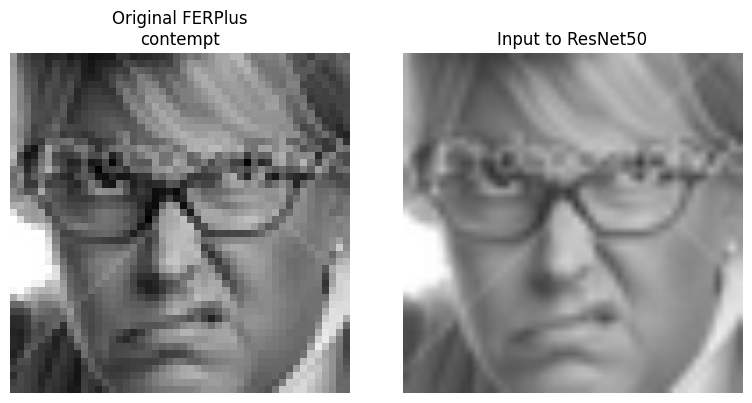

In [ ]:
sample_idx = 0

row = ferplus_test_df.iloc[
    sample_idx
]

original = pixels_to_image(
    row["pixels"]
)

processed_tensor, label = (
    ferplus_test_dataset[
        sample_idx
    ]
)

processed = denormalize_image(
    processed_tensor
)

processed = processed.permute(
    1, 2, 0
).numpy()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(8, 4)
)

axes[0].imshow(
    original,
    cmap="gray"
)

axes[0].set_title(
    f"Original FERPlus\n{row['emotion']}"
)

axes[0].axis("off")

axes[1].imshow(
    processed
)

axes[1].set_title(
    "Input to ResNet50"
)

axes[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
images, labels = next(
    iter(
        ferplus_test_loader
    )
)

print("FERPlus tensor statistics")

print(
    "Min:",
    images.min().item()
)

print(
    "Max:",
    images.max().item()
)

print(
    "Mean:",
    images.mean().item()
)

print(
    "Std:",
    images.std().item()
)

FERPlus tensor statistics
Min: -2.1179039478302
Max: 2.640000104904175
Mean: 0.18320949375629425
Std: 1.141424298286438


In [ ]:
AFFECTNET_TEST_CSV = os.path.join(
    RESULT_DIR,
    "dataset_splits",
    "affectnet_test.csv"
)

affectnet_test_df = pd.read_csv(
    AFFECTNET_TEST_CSV
)

print(
    affectnet_test_df.head()
)

print(
    affectnet_test_df.columns
)

                                                path emotion  label
0  /content/drive/MyDrive/Emotion_Recognition_The...   anger      0
1  /content/drive/MyDrive/Emotion_Recognition_The...   anger      0
2  /content/drive/MyDrive/Emotion_Recognition_The...   anger      0
3  /content/drive/MyDrive/Emotion_Recognition_The...   anger      0
4  /content/drive/MyDrive/Emotion_Recognition_The...   anger      0
Index(['path', 'emotion', 'label'], dtype='object')


In [ ]:
class AffectNetDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.dataframe = (
            dataframe
            .reset_index(drop=True)
        )

        self.transform = transform

    def __len__(self):

        return len(
            self.dataframe
        )

    def __getitem__(
        self,
        idx
    ):

        row = self.dataframe.iloc[
            idx
        ]

        image = Image.open(
            row["filepath"]
        ).convert("RGB")

        label = int(
            row["label"]
        )

        if self.transform:

            image = self.transform(
                image
            )

        return image, label

In [ ]:
eval_transform = transforms.Compose([
    transforms.Resize(
        (224, 224)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

In [ ]:
affectnet_test_dataset = AffectNetDataset(
    affectnet_test_df,
    transform=eval_transform
)

affectnet_test_loader = DataLoader(
    affectnet_test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
print(
    affectnet_test_df.columns.tolist()
)

print()

print(
    affectnet_test_df.head()
)

['path', 'emotion', 'label']

                                                path emotion  label
0  /content/drive/MyDrive/Emotion_Recognition_The...   anger      0
1  /content/drive/MyDrive/Emotion_Recognition_The...   anger      0
2  /content/drive/MyDrive/Emotion_Recognition_The...   anger      0
3  /content/drive/MyDrive/Emotion_Recognition_The...   anger      0
4  /content/drive/MyDrive/Emotion_Recognition_The...   anger      0


In [ ]:
class AffectNetDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):
        self.dataframe = dataframe.reset_index(
            drop=True
        )

        self.transform = transform

        possible_path_columns = [
            "filepath",
            "file_path",
            "path",
            "image_path",
            "image",
            "filename"
        ]

        self.path_column = None

        for col in possible_path_columns:
            if col in self.dataframe.columns:
                self.path_column = col
                break

        if self.path_column is None:
            raise ValueError(
                "No image path column found. "
                f"Available columns: "
                f"{self.dataframe.columns.tolist()}"
            )

        print(
            "Using image path column:",
            self.path_column
        )

    def __len__(self):
        return len(
            self.dataframe
        )

    def __getitem__(
        self,
        idx
    ):
        row = self.dataframe.iloc[
            idx
        ]

        image = Image.open(
            row[
                self.path_column
            ]
        ).convert(
            "RGB"
        )

        label = int(
            row["label"]
        )

        if self.transform:
            image = self.transform(
                image
            )

        return image, label

In [ ]:
affectnet_test_dataset = AffectNetDataset(
    affectnet_test_df,
    transform=eval_transform
)

affectnet_test_loader = DataLoader(
    affectnet_test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

Using image path column: path


In [ ]:
aff_images, aff_labels = next(
    iter(
        affectnet_test_loader
    )
)

print("AffectNet tensor statistics")

print(
    "Min:",
    aff_images.min().item()
)

print(
    "Max:",
    aff_images.max().item()
)

print(
    "Mean:",
    aff_images.mean().item()
)

print(
    "Std:",
    aff_images.std().item()
)

AffectNet tensor statistics
Min: -2.1179039478302
Max: 2.640000104904175
Mean: -0.00028403528267517686
Std: 1.1630957126617432


##Side-by-side visual domain comparison

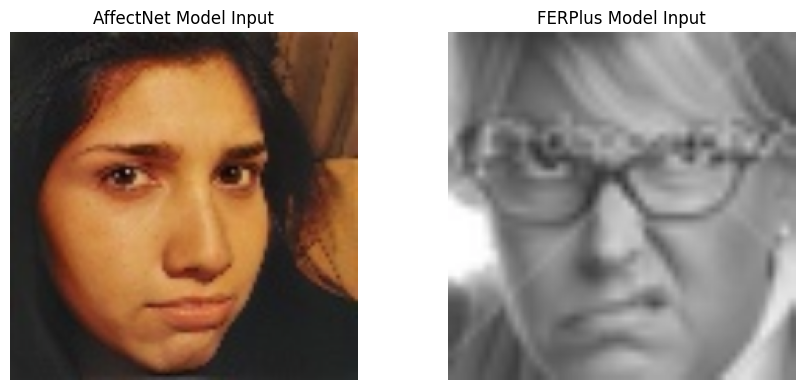

In [ ]:
aff_tensor, aff_label = (
    affectnet_test_dataset[0]
)

fer_tensor, fer_label = (
    ferplus_test_dataset[0]
)

aff_display = denormalize_image(
    aff_tensor
).permute(
    1, 2, 0
).numpy()

fer_display = denormalize_image(
    fer_tensor
).permute(
    1, 2, 0
).numpy()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(9, 4)
)

axes[0].imshow(
    aff_display
)

axes[0].set_title(
    "AffectNet Model Input"
)

axes[0].axis("off")

axes[1].imshow(
    fer_display
)

axes[1].set_title(
    "FERPlus Model Input"
)

axes[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
affectnet_gray_transform = transforms.Compose([
    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.Resize(
        (224, 224)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

In [ ]:
affectnet_gray_dataset = AffectNetDataset(
    affectnet_test_df,
    transform=affectnet_gray_transform
)

affectnet_gray_loader = DataLoader(
    affectnet_gray_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

Using image path column: path


In [ ]:
affectnet_gray_results = (
    evaluate_external_model(
        weighted_resnet,
        affectnet_gray_loader,
        device
    )
)

print(
    "=== AffectNet Grayscale Diagnostic ==="
)

print(
    f"Accuracy: "
    f"{affectnet_gray_results['accuracy']:.4f}"
)

print(
    f"Macro F1: "
    f"{affectnet_gray_results['macro_f1']:.4f}"
)

=== AffectNet Grayscale Diagnostic ===
Accuracy: 0.4414
Macro F1: 0.3923


**Key Points:**

* Converting AffectNet itself to grayscale reduces accuracy by 15.00 percentage points and Macro-F1 by 14.20 points, so color information clearly matters to the model. But grayscale alone does not explain the FERPlus collapse: compared with grayscale AffectNet, FERPlus still drops another 35.19 accuracy points and 33.72 Macro-F1 points.

* That supports a broader domain-shift explanation involving resolution, image quality, cropping/alignment, annotation style, visual statistics, and dataset composition.



#**Part C: Cross-domain analysis**

##Save the grayscale diagnostic

In [ ]:
grayscale_diagnostic = pd.DataFrame({
    "Condition": [
        "AffectNet RGB",
        "AffectNet Grayscale",
        "FERPlus"
    ],
    "Accuracy": [
        0.5942,
        affectnet_gray_results["accuracy"],
        ferplus_results["accuracy"]
    ],
    "Macro_F1": [
        0.5517,
        affectnet_gray_results["macro_f1"],
        ferplus_results["macro_f1"]
    ]
})

grayscale_diagnostic

,Condition,Accuracy,Macro_F1
0,AffectNet RGB,0.594200,0.551700
1,AffectNet Grayscale,0.441383,0.392291
2,FERPlus,0.074386,0.067386


In [ ]:
grayscale_diagnostic.to_csv(
    os.path.join(
        FERPLUS_RESULT_DIR,
        "grayscale_domain_diagnostic.csv"
    ),
    index=False
)

##Plotting the domain-performance comparison

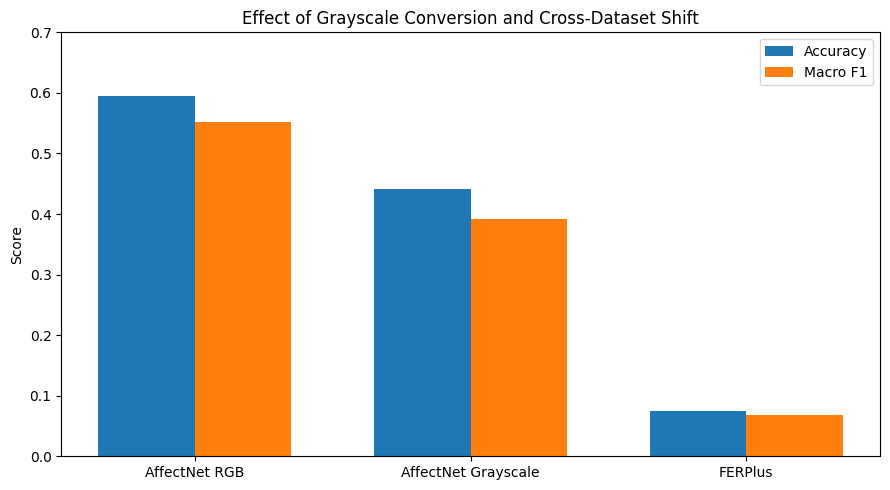

In [ ]:
x = np.arange(
    len(grayscale_diagnostic)
)

width = 0.35

fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.bar(
    x - width/2,
    grayscale_diagnostic["Accuracy"],
    width,
    label="Accuracy"
)

ax.bar(
    x + width/2,
    grayscale_diagnostic["Macro_F1"],
    width,
    label="Macro F1"
)

ax.set_xticks(x)

ax.set_xticklabels(
    grayscale_diagnostic[
        "Condition"
    ]
)

ax.set_ylabel(
    "Score"
)

ax.set_ylim(
    0,
    0.7
)

ax.set_title(
    "Effect of Grayscale Conversion and Cross-Dataset Shift"
)

ax.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        FERPLUS_RESULT_DIR,
        "domain_shift_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##FERPlus normalized confusion matrix

In [ ]:
ferplus_cm = confusion_matrix(
    ferplus_results["y_true"],
    ferplus_results["y_pred"],
    labels=list(range(NUM_CLASSES)),
    normalize="true"
)

print(
    np.round(
        ferplus_cm,
        3
    )
)

[[0.178 0.    0.023 0.603 0.    0.    0.192 0.005]
 [0.    0.111 0.111 0.556 0.    0.    0.222 0.   ]
 [0.286 0.    0.    0.286 0.    0.    0.429 0.   ]
 [0.    0.    0.    0.98  0.    0.    0.    0.02 ]
 [0.084 0.028 0.017 0.708 0.    0.    0.162 0.002]
 [0.101 0.022 0.004 0.607 0.    0.    0.264 0.001]
 [0.092 0.    0.007 0.529 0.    0.    0.373 0.   ]
 [0.006 0.    0.    0.941 0.    0.    0.041 0.012]]


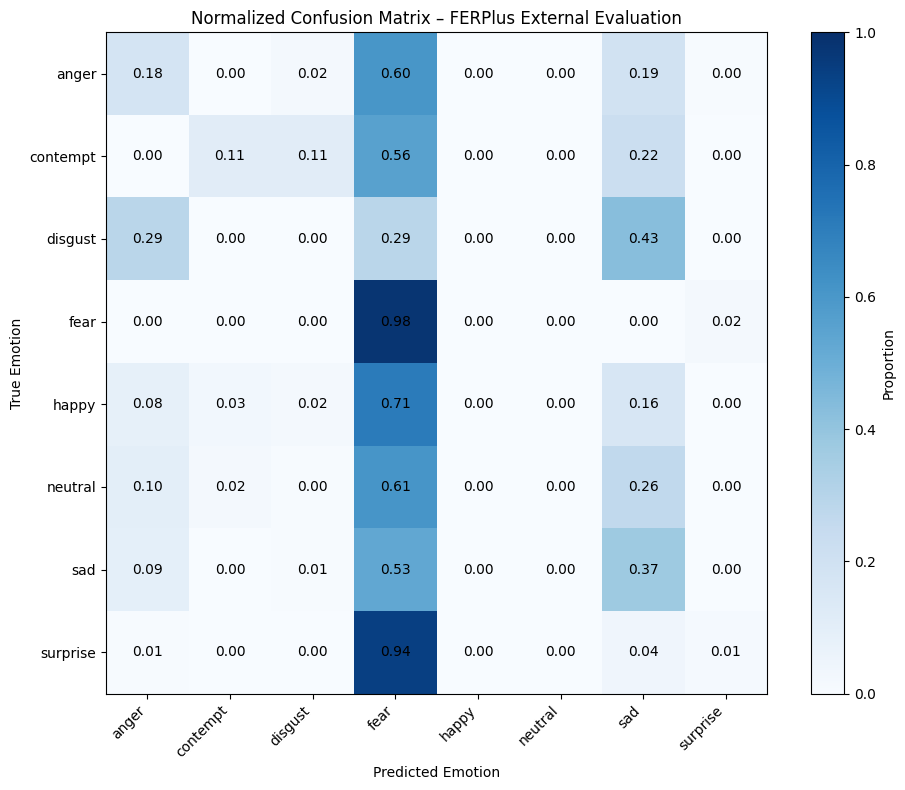

In [ ]:
fig, ax = plt.subplots(
    figsize=(10, 8)
)

im = ax.imshow(
    ferplus_cm,
    cmap="Blues",
    vmin=0,
    vmax=1
)

ax.set_xticks(
    np.arange(NUM_CLASSES)
)

ax.set_yticks(
    np.arange(NUM_CLASSES)
)

ax.set_xticklabels(
    EMOTION_CLASSES,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    EMOTION_CLASSES
)

ax.set_xlabel(
    "Predicted Emotion"
)

ax.set_ylabel(
    "True Emotion"
)

ax.set_title(
    "Normalized Confusion Matrix – FERPlus External Evaluation"
)

for i in range(NUM_CLASSES):

    for j in range(NUM_CLASSES):

        value = ferplus_cm[i, j]

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center"
        )

fig.colorbar(
    im,
    ax=ax,
    label="Proportion"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FERPLUS_RESULT_DIR,
        "ferplus_normalized_confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##Compare class performance across domains

In [ ]:
affectnet_f1 = {
    "anger": 0.4338,
    "contempt": 0.5666,
    "disgust": 0.4055,
    "fear": 0.4580,
    "happy": 0.8533,
    "neutral": 0.7690,
    "sad": 0.5313,
    "surprise": 0.3958
}

In [ ]:
ferplus_class_report = classification_report(
    ferplus_results["y_true"],
    ferplus_results["y_pred"],
    labels=list(range(NUM_CLASSES)),
    target_names=EMOTION_CLASSES,
    output_dict=True,
    zero_division=0
)

In [ ]:
class_domain_comparison = pd.DataFrame({
    "Emotion": EMOTION_CLASSES,

    "AffectNet_F1": [
        affectnet_f1[
            emotion
        ]
        for emotion in EMOTION_CLASSES
    ],

    "FERPlus_F1": [
        ferplus_class_report[
            emotion
        ]["f1-score"]
        for emotion in EMOTION_CLASSES
    ]
})

In [ ]:
class_domain_comparison[
    "F1_Drop"
] = (
    class_domain_comparison[
        "AffectNet_F1"
    ]
    -
    class_domain_comparison[
        "FERPlus_F1"
    ]
)

class_domain_comparison

,Emotion,AffectNet_F1,FERPlus_F1,F1_Drop
0,anger,0.4338,0.170678,0.263122
1,contempt,0.5666,0.036364,0.530236
2,disgust,0.4055,0.000000,0.405500
3,fear,0.4580,0.051579,0.406421
4,happy,0.8533,0.000000,0.853300
5,neutral,0.7690,0.000000,0.769000
6,sad,0.5313,0.257611,0.273689
7,surprise,0.3958,0.022857,0.372943


In [ ]:
class_domain_comparison.to_csv(
    os.path.join(
        FERPLUS_RESULT_DIR,
        "class_level_domain_comparison.csv"
    ),
    index=False
)

##Plot class-by-class degradation

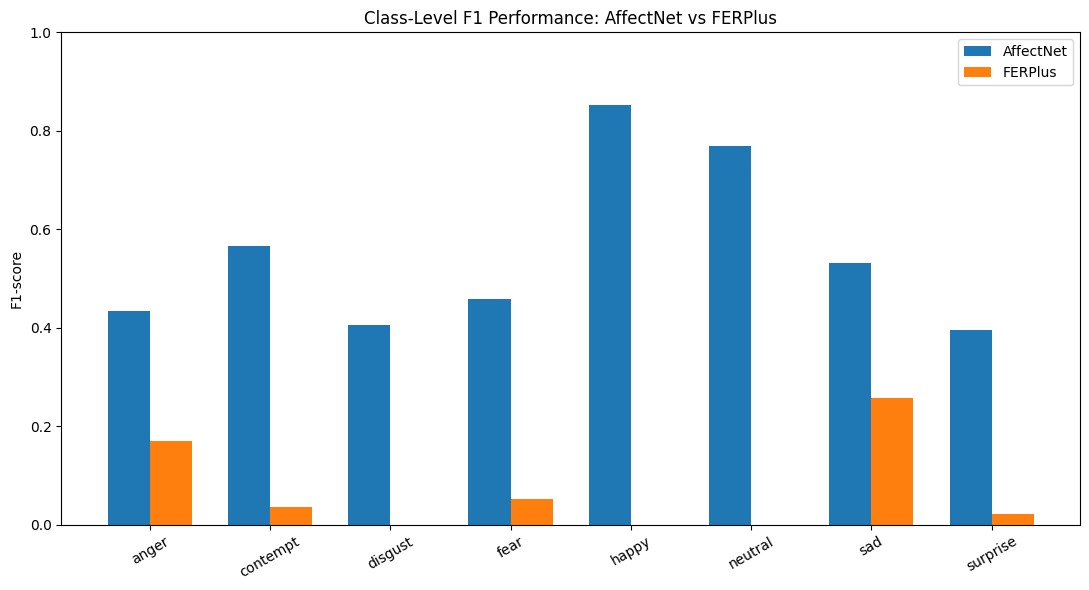

In [ ]:
x = np.arange(
    len(EMOTION_CLASSES)
)

width = 0.35

fig, ax = plt.subplots(
    figsize=(11, 6)
)

ax.bar(
    x - width/2,
    class_domain_comparison[
        "AffectNet_F1"
    ],
    width,
    label="AffectNet"
)

ax.bar(
    x + width/2,
    class_domain_comparison[
        "FERPlus_F1"
    ],
    width,
    label="FERPlus"
)

ax.set_xticks(x)

ax.set_xticklabels(
    EMOTION_CLASSES,
    rotation=30
)

ax.set_ylabel(
    "F1-score"
)

ax.set_ylim(
    0,
    1
)

ax.set_title(
    "Class-Level F1 Performance: AffectNet vs FERPlus"
)

ax.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        FERPLUS_RESULT_DIR,
        "class_level_cross_domain_f1.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##Prediction bias analysis

In [ ]:
prediction_distribution = pd.DataFrame({
    "Emotion": EMOTION_CLASSES,

    "True_Count": [
        np.sum(
            ferplus_results[
                "y_true"
            ] == i
        )
        for i in range(NUM_CLASSES)
    ],

    "Predicted_Count": [
        np.sum(
            ferplus_results[
                "y_pred"
            ] == i
        )
        for i in range(NUM_CLASSES)
    ]
})

prediction_distribution[
    "True_Percentage"
] = (
    prediction_distribution[
        "True_Count"
    ]
    / len(
        ferplus_results[
            "y_true"
        ]
    )
    * 100
)

prediction_distribution[
    "Predicted_Percentage"
] = (
    prediction_distribution[
        "Predicted_Count"
    ]
    / len(
        ferplus_results[
            "y_pred"
        ]
    )
    * 100
)

prediction_distribution

,Emotion,True_Count,Predicted_Count,True_Percentage,Predicted_Percentage
0,anger,219,238,8.024918,8.721143
1,contempt,9,46,0.329791,1.685599
2,disgust,7,27,0.256504,0.989373
3,fear,50,1850,1.832173,67.790399
4,happy,872,0,31.953096,0.000000
5,neutral,936,0,34.298278,0.000000
6,sad,295,559,10.809820,20.483694
7,surprise,341,9,12.495420,0.329791


In [ ]:
prediction_distribution.to_csv(
    os.path.join(
        FERPLUS_RESULT_DIR,
        "ferplus_prediction_distribution.csv"
    ),
    index=False
)

##High-confidence errors

In [ ]:
errors_df = (
    ferplus_predictions_df[
        ferplus_predictions_df[
            "correct"
        ] == False
    ]
    .copy()
)

errors_df = errors_df.sort_values(
    "confidence",
    ascending=False
).reset_index(drop=True)

print(
    "Total incorrect predictions:",
    len(errors_df)
)

errors_df[
    [
        "emotion",
        "predicted_emotion",
        "confidence"
    ]
].head(20)

Total incorrect predictions: 2526


,emotion,predicted_emotion,confidence
0,surprise,fear,0.977723
1,surprise,fear,0.970624
2,surprise,fear,0.970033
3,anger,fear,0.969459
4,surprise,fear,0.967846
5,happy,fear,0.964875
6,surprise,fear,0.964602
7,surprise,fear,0.962839
8,anger,fear,0.957785
9,anger,fear,0.957013


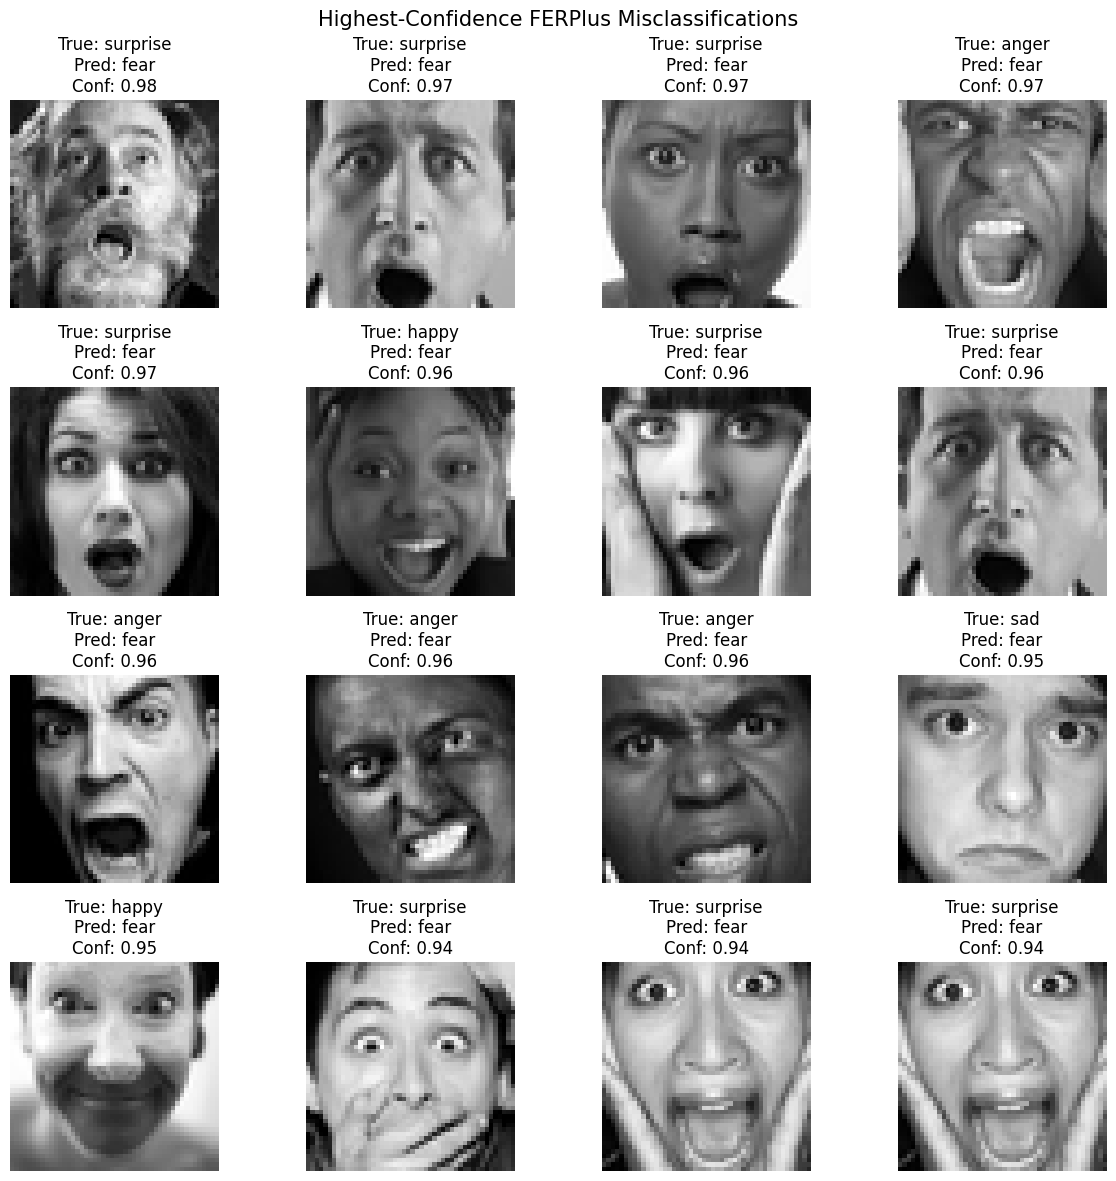

In [ ]:
fig, axes = plt.subplots(
    4,
    4,
    figsize=(12, 12)
)

for ax, (_, row) in zip(
    axes.flatten(),
    errors_df.head(16).iterrows()
):

    image = pixels_to_image(
        row["pixels"]
    )

    ax.imshow(
        image,
        cmap="gray"
    )

    ax.set_title(
        f"True: {row['emotion']}\n"
        f"Pred: {row['predicted_emotion']}\n"
        f"Conf: {row['confidence']:.2f}"
    )

    ax.axis("off")

plt.suptitle(
    "Highest-Confidence FERPlus Misclassifications",
    fontsize=15
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FERPLUS_RESULT_DIR,
        "high_confidence_errors.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##Correct prediction examples

In [ ]:
correct_df = (
    ferplus_predictions_df[
        ferplus_predictions_df[
            "correct"
        ] == True
    ]
    .sort_values(
        "confidence",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Correct predictions:",
    len(correct_df)
)

Correct predictions: 203


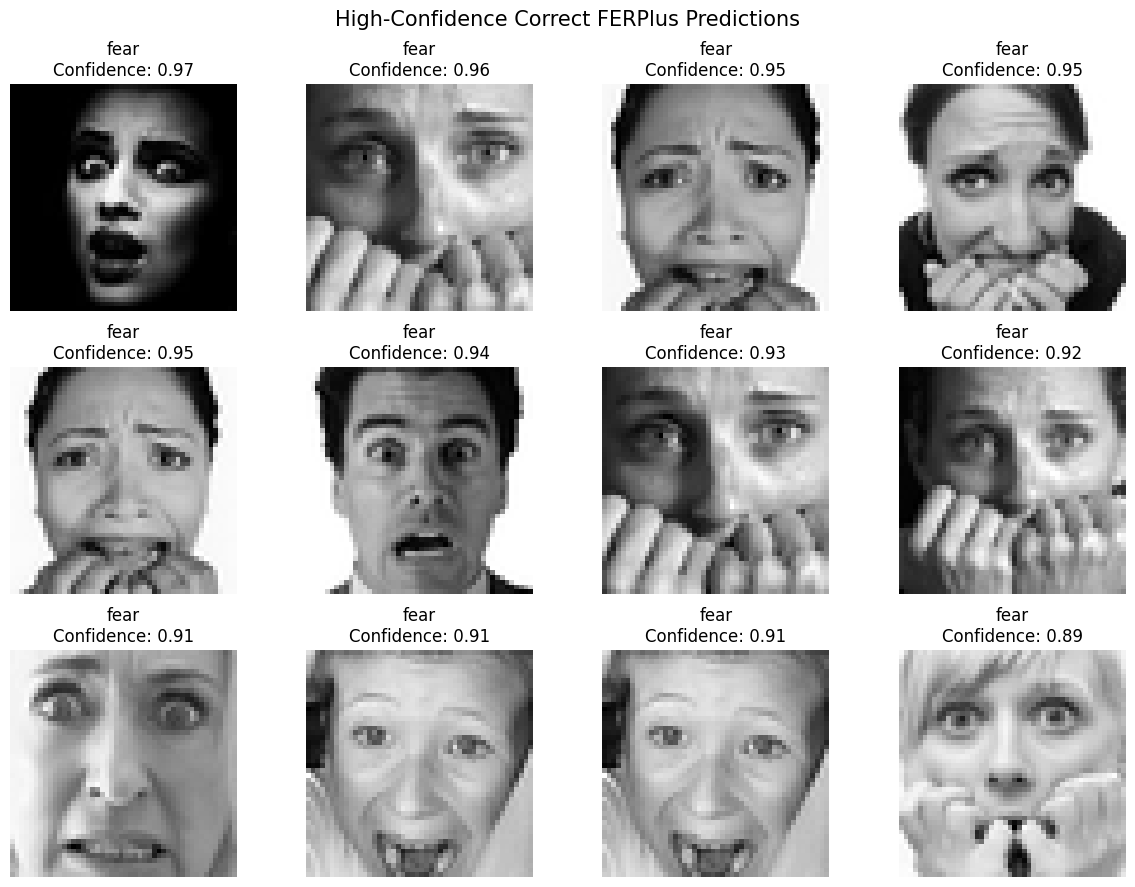

In [ ]:
fig, axes = plt.subplots(
    3,
    4,
    figsize=(12, 9)
)

for ax, (_, row) in zip(
    axes.flatten(),
    correct_df.head(12).iterrows()
):

    image = pixels_to_image(
        row["pixels"]
    )

    ax.imshow(
        image,
        cmap="gray"
    )

    ax.set_title(
        f"{row['emotion']}\n"
        f"Confidence: {row['confidence']:.2f}"
    )

    ax.axis("off")

plt.suptitle(
    "High-Confidence Correct FERPlus Predictions",
    fontsize=15
)

plt.tight_layout()
plt.show()

#**Part D — Grad-CAM Explainability**

##Grad-CAM implementation

In [ ]:
class GradCAM:

    def __init__(
        self,
        model,
        target_layer
    ):

        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self.forward_handle = (
            target_layer.register_forward_hook(
                self._forward_hook
            )
        )

        self.backward_handle = (
            target_layer.register_full_backward_hook(
                self._backward_hook
            )
        )

    def _forward_hook(
        self,
        module,
        input,
        output
    ):
        self.activations = output.detach()

    def _backward_hook(
        self,
        module,
        grad_input,
        grad_output
    ):
        self.gradients = (
            grad_output[0].detach()
        )

    def generate(
        self,
        input_tensor,
        target_class=None
    ):

        self.model.eval()

        input_tensor = input_tensor.to(
            device
        )

        self.model.zero_grad()

        output = self.model(
            input_tensor
        )

        probabilities = torch.softmax(
            output,
            dim=1
        )

        predicted_class = output.argmax(
            dim=1
        ).item()

        if target_class is None:
            target_class = predicted_class

        score = output[
            0,
            target_class
        ]

        score.backward()

        gradients = self.gradients
        activations = self.activations

        weights = gradients.mean(
            dim=(2, 3),
            keepdim=True
        )

        cam = (
            weights * activations
        ).sum(
            dim=1,
            keepdim=True
        )

        cam = torch.relu(
            cam
        )

        cam = torch.nn.functional.interpolate(
            cam,
            size=input_tensor.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        cam = cam.squeeze()

        cam -= cam.min()

        if cam.max() > 0:
            cam /= cam.max()

        confidence = probabilities[
            0,
            predicted_class
        ].item()

        return (
            cam.cpu().numpy(),
            predicted_class,
            confidence
        )

    def remove_hooks(self):

        self.forward_handle.remove()
        self.backward_handle.remove()

##Initialize Grad-CAM

In [ ]:
gradcam = GradCAM(
    model=weighted_resnet,
    target_layer=weighted_resnet.layer4[-1]
)

print(
    "Grad-CAM initialized."
)

Grad-CAM initialized.


##Heatmap overlay function

In [ ]:
def create_gradcam_overlay(
    original_image,
    heatmap,
    alpha=0.45
):

    import matplotlib.cm as cm

    if original_image.ndim == 2:

        original_rgb = np.stack(
            [
                original_image,
                original_image,
                original_image
            ],
            axis=-1
        )

    else:
        original_rgb = (
            original_image.copy()
        )

    original_rgb = (
        original_rgb.astype(
            np.float32
        )
        / 255.0
    )

    heatmap_resized = Image.fromarray(
        np.uint8(
            heatmap * 255
        )
    ).resize(
        (
            original_rgb.shape[1],
            original_rgb.shape[0]
        )
    )

    heatmap_resized = (
        np.array(
            heatmap_resized
        )
        / 255.0
    )

    heatmap_color = cm.jet(
        heatmap_resized
    )[:, :, :3]

    overlay = (
        (1 - alpha)
        * original_rgb
        +
        alpha
        * heatmap_color
    )

    overlay = np.clip(
        overlay,
        0,
        1
    )

    return overlay

##Function for a single FERPlus Grad-CAM

In [ ]:
def analyze_ferplus_gradcam(
    dataset_index
):

    row = ferplus_test_df.iloc[
        dataset_index
    ]

    input_tensor, true_label = (
        ferplus_test_dataset[
            dataset_index
        ]
    )

    cam, predicted_class, confidence = (
        gradcam.generate(
            input_tensor.unsqueeze(0)
        )
    )

    original_image = pixels_to_image(
        row["pixels"]
    )

    overlay = create_gradcam_overlay(
        original_image,
        cam
    )

    true_emotion = EMOTION_CLASSES[
        true_label
    ]

    predicted_emotion = (
        EMOTION_CLASSES[
            predicted_class
        ]
    )

    return {
        "original":
            original_image,

        "heatmap":
            cam,

        "overlay":
            overlay,

        "true":
            true_emotion,

        "predicted":
            predicted_emotion,

        "confidence":
            confidence
    }

#Finding indices for correct and incorrect examples

In [ ]:
ferplus_predictions_df[
    "dataset_index"
] = np.arange(
    len(
        ferplus_predictions_df
    )
)

In [ ]:
correct_examples = (
    ferplus_predictions_df[
        ferplus_predictions_df[
            "correct"
        ]
    ]
    .sort_values(
        "confidence",
        ascending=False
    )
)

correct_indices = (
    correct_examples[
        "dataset_index"
    ]
    .head(4)
    .tolist()
)

print(
    "Correct indices:",
    correct_indices
)

Correct indices: [1880, 689, 373, 1551]


In [ ]:
incorrect_examples = (
    ferplus_predictions_df[
        ~ferplus_predictions_df[
            "correct"
        ]
    ]
    .sort_values(
        "confidence",
        ascending=False
    )
)

incorrect_indices = (
    incorrect_examples[
        "dataset_index"
    ]
    .head(4)
    .tolist()
)

print(
    "Incorrect indices:",
    incorrect_indices
)

Incorrect indices: [65, 2005, 713, 2]


##Grad-CAM for correct predictions

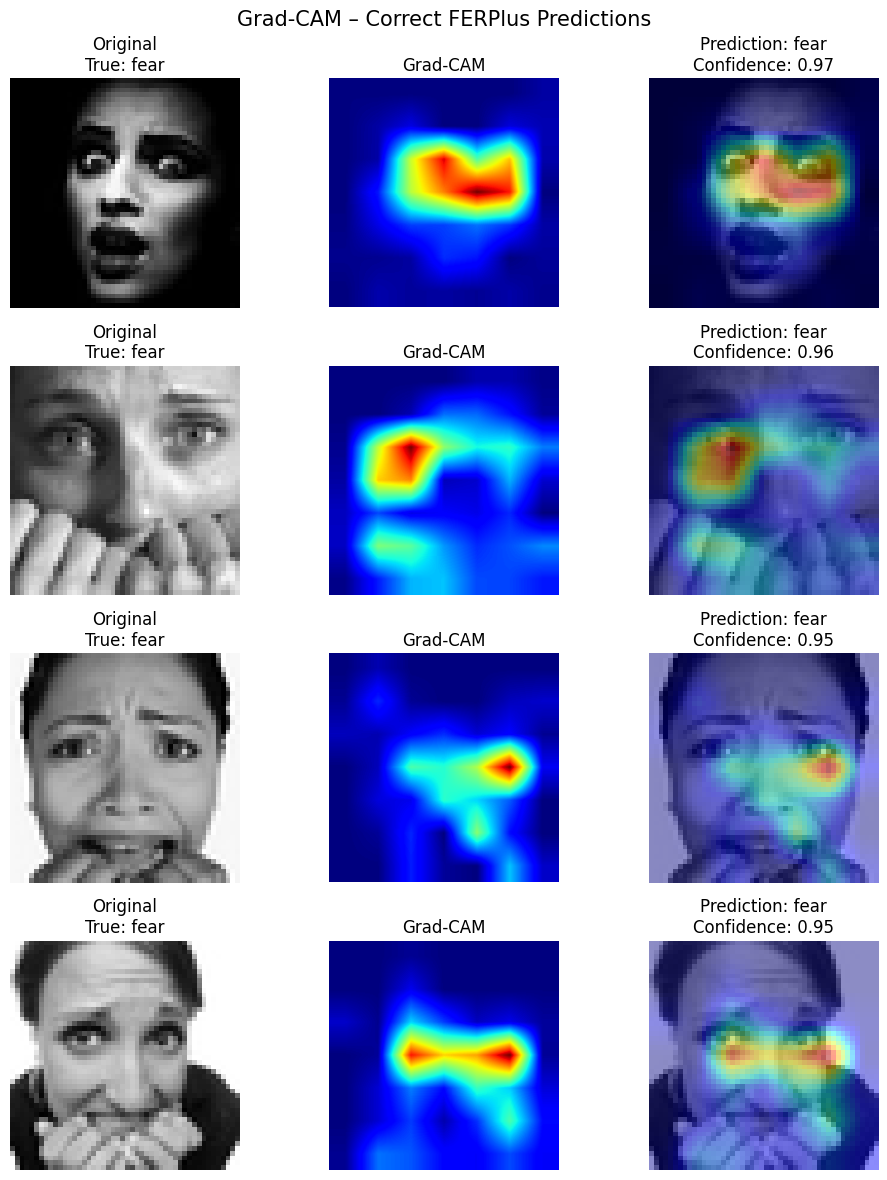

In [ ]:
fig, axes = plt.subplots(
    len(correct_indices),
    3,
    figsize=(
        10,
        3 * len(correct_indices)
    )
)

for row_idx, dataset_idx in enumerate(
    correct_indices
):

    result = analyze_ferplus_gradcam(
        dataset_idx
    )

    axes[row_idx, 0].imshow(
        result["original"],
        cmap="gray"
    )

    axes[row_idx, 0].set_title(
        f"Original\n"
        f"True: {result['true']}"
    )

    axes[row_idx, 1].imshow(
        result["heatmap"],
        cmap="jet"
    )

    axes[row_idx, 1].set_title(
        "Grad-CAM"
    )

    axes[row_idx, 2].imshow(
        result["overlay"]
    )

    axes[row_idx, 2].set_title(
        f"Prediction: "
        f"{result['predicted']}\n"
        f"Confidence: "
        f"{result['confidence']:.2f}"
    )

    for col in range(3):
        axes[row_idx, col].axis(
            "off"
        )

plt.suptitle(
    "Grad-CAM – Correct FERPlus Predictions",
    fontsize=15
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FERPLUS_RESULT_DIR,
        "gradcam_correct_ferplus.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##Grad-CAM for incorrect predictions

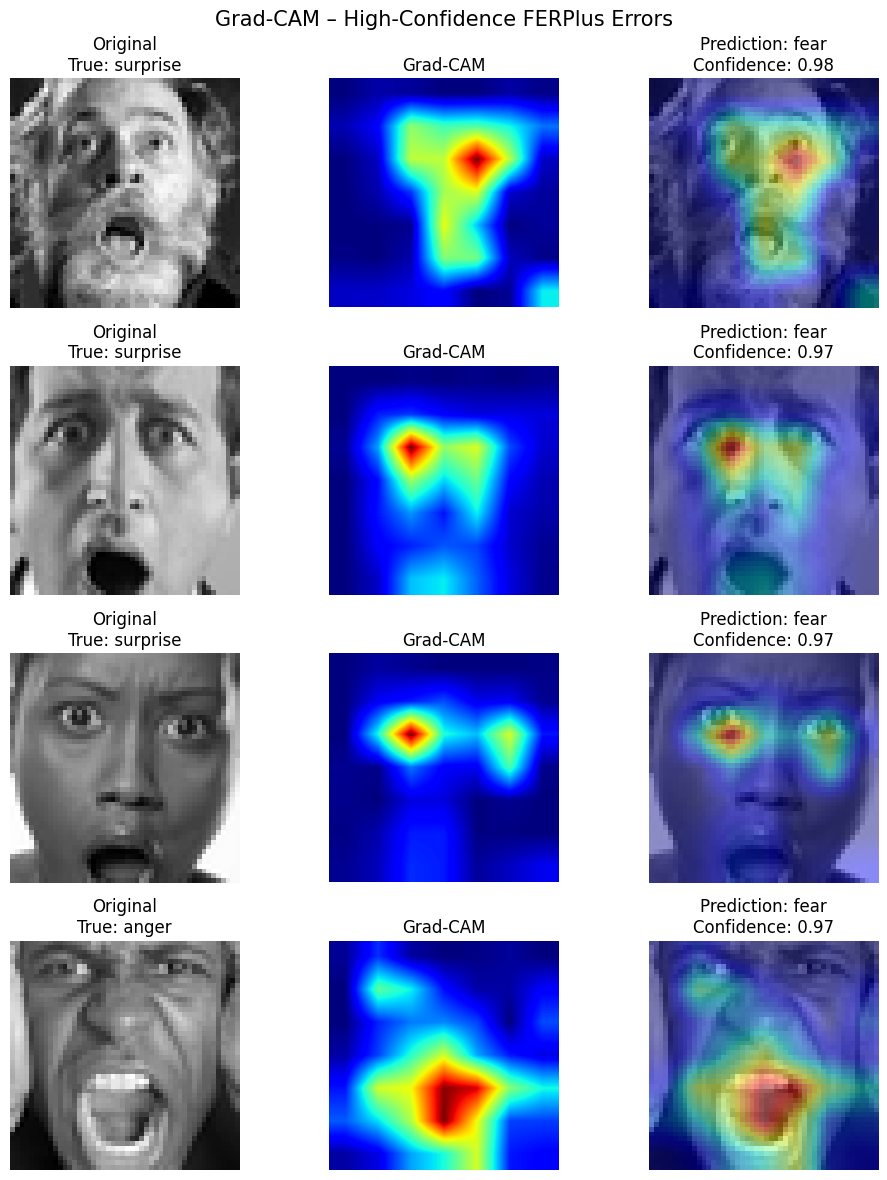

In [ ]:
fig, axes = plt.subplots(
    len(incorrect_indices),
    3,
    figsize=(
        10,
        3 * len(incorrect_indices)
    )
)

for row_idx, dataset_idx in enumerate(
    incorrect_indices
):

    result = analyze_ferplus_gradcam(
        dataset_idx
    )

    axes[row_idx, 0].imshow(
        result["original"],
        cmap="gray"
    )

    axes[row_idx, 0].set_title(
        f"Original\n"
        f"True: {result['true']}"
    )

    axes[row_idx, 1].imshow(
        result["heatmap"],
        cmap="jet"
    )

    axes[row_idx, 1].set_title(
        "Grad-CAM"
    )

    axes[row_idx, 2].imshow(
        result["overlay"]
    )

    axes[row_idx, 2].set_title(
        f"Prediction: "
        f"{result['predicted']}\n"
        f"Confidence: "
        f"{result['confidence']:.2f}"
    )

    for col in range(3):
        axes[row_idx, col].axis(
            "off"
        )

plt.suptitle(
    "Grad-CAM – High-Confidence FERPlus Errors",
    fontsize=15
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FERPLUS_RESULT_DIR,
        "gradcam_incorrect_ferplus.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
confusion_pairs = (
    ferplus_predictions_df[
        ~ferplus_predictions_df[
            "correct"
        ]
    ]
    .groupby(
        [
            "emotion",
            "predicted_emotion"
        ]
    )
    .size()
    .reset_index(
        name="count"
    )
    .sort_values(
        "count",
        ascending=False
    )
)

confusion_pairs.head(15)

,emotion,predicted_emotion,count
14,happy,fear,617
20,neutral,fear,568
27,surprise,fear,321
21,neutral,sad,247
25,sad,fear,156
15,happy,sad,141
1,anger,fear,132
17,neutral,anger,95
11,happy,anger,73
2,anger,sad,42


##Selecting representative errors

In [ ]:
representative_errors = []

top_pairs = confusion_pairs.head(
    6
)

for _, pair in top_pairs.iterrows():

    candidates = (
        ferplus_predictions_df[
            (
                ferplus_predictions_df[
                    "emotion"
                ]
                ==
                pair["emotion"]
            )
            &
            (
                ferplus_predictions_df[
                    "predicted_emotion"
                ]
                ==
                pair[
                    "predicted_emotion"
                ]
            )
        ]
        .sort_values(
            "confidence",
            ascending=False
        )
    )

    if len(candidates) > 0:

        representative_errors.append(
            int(
                candidates.iloc[0][
                    "dataset_index"
                ]
            )
        )

print(
    representative_errors
)

[2316, 2523, 65, 504, 543, 1913]


##Grad-CAM representative failure modes

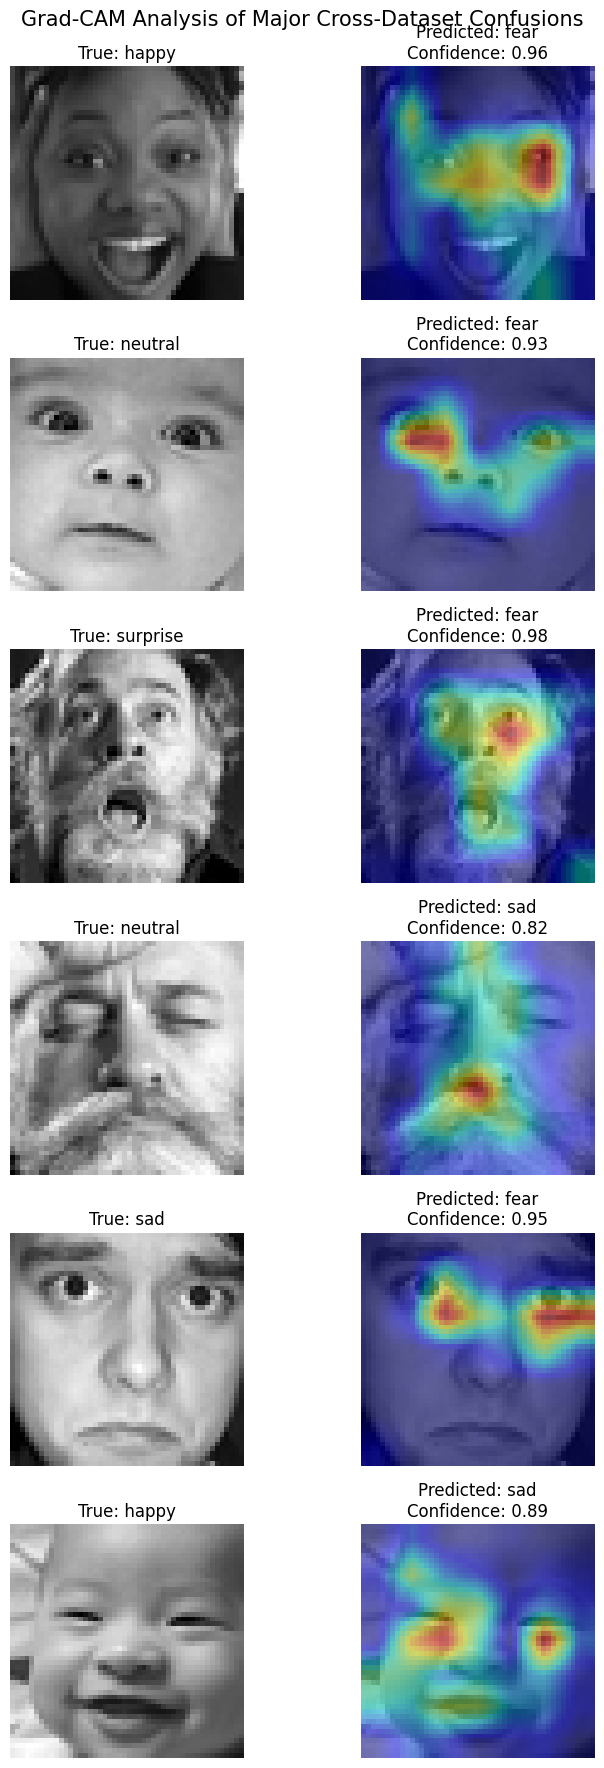

In [ ]:
fig, axes = plt.subplots(
    len(representative_errors),
    2,
    figsize=(
        8,
        3 * len(
            representative_errors
        )
    )
)

for row_idx, dataset_idx in enumerate(
    representative_errors
):

    result = analyze_ferplus_gradcam(
        dataset_idx
    )

    axes[row_idx, 0].imshow(
        result["original"],
        cmap="gray"
    )

    axes[row_idx, 0].set_title(
        f"True: {result['true']}"
    )

    axes[row_idx, 1].imshow(
        result["overlay"]
    )

    axes[row_idx, 1].set_title(
        f"Predicted: "
        f"{result['predicted']}\n"
        f"Confidence: "
        f"{result['confidence']:.2f}"
    )

    axes[row_idx, 0].axis("off")
    axes[row_idx, 1].axis("off")

plt.suptitle(
    "Grad-CAM Analysis of Major Cross-Dataset Confusions",
    fontsize=15
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FERPLUS_RESULT_DIR,
        "gradcam_major_confusions.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##Simple structured error table

In [ ]:
confusion_pairs.to_csv(
    os.path.join(
        FERPLUS_RESULT_DIR,
        "ferplus_confusion_pairs.csv"
    ),
    index=False
)

confusion_pairs.head(15)

,emotion,predicted_emotion,count
14,happy,fear,617
20,neutral,fear,568
27,surprise,fear,321
21,neutral,sad,247
25,sad,fear,156
15,happy,sad,141
1,anger,fear,132
17,neutral,anger,95
11,happy,anger,73
2,anger,sad,42


We have a substantial result:

AffectNet RGB

* Accuracy: 59.42%
* Macro-F1: 55.17%

AffectNet grayscale diagnostic

* Accuracy: 44.42%
* Macro-F1: 40.97%

FERPlus zero-adaptation external evaluation

* Accuracy: 9.23%
* Macro-F1: 7.25%